# 14 — Walk-forward robustness + filtered portfolio

(1) Walk-forward: 4 expanding folds, each trains only on its past and predicts
the next block — confirms the classifier isn't a single-split fluke.
(2) Collect those honest OOS predictions and run the $1000/$20 portfolio on the
**filtered** events (model predicts profit) vs trading all.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *
import heapq
from sklearn.ensemble import HistGradientBoostingRegressor

d = np.load('_out/pump_features_3y.npz', allow_pickle=True)
X, y, ts, off = d['X'], d['y'], d['ts'], d['off']
o = np.argsort(ts); X, y, ts, off = X[o], y[o], ts[o], off[o]
N = len(y)

def fit_model():
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
                                         l2_regularization=1.0, min_samples_leaf=50, random_state=0)

bounds = [0.40, 0.55, 0.70, 0.85, 1.00]
pred_all = np.full(N, np.nan)
print(f"{'fold test window':<28}{'n':>6}{'corr':>7}{'all':>9}{'top50':>9}")
for a, b in zip(bounds[:-1], bounds[1:]):
    i0, i1 = int(N*a), int(N*b)
    m = fit_model().fit(X[:i0], y[:i0])
    p = m.predict(X[i0:i1]); pred_all[i0:i1] = p
    yy = y[i0:i1]
    top = yy[np.argsort(-p)[:len(p)//2]]
    d0, d1 = pd.to_datetime(ts[i0]).date(), pd.to_datetime(ts[i1-1]).date()
    print(f'{str(d0)+".."+str(d1):<28}{len(p):>6}{np.corrcoef(p,yy)[0,1]:>+7.2f}'
          f'{yy.mean()*100:>+8.2f}%{top.mean()*100:>+8.2f}%')

fold test window                 n   corr      all    top50


2024-11-10..2025-02-03        1125  +0.27   +0.99%   +1.82%
2025-02-03..2025-06-11        1125  +0.27   +0.61%   +1.67%
2025-06-11..2025-11-19        1125  +0.33   +0.78%   +2.05%


2025-11-20..2026-04-30        1125  +0.28   +1.30%   +2.51%


In [2]:
# OOS region = where we have walk-forward predictions
mask = ~np.isnan(pred_all)
ts_o, y_o, off_o, pr_o = ts[mask], y[mask], off[mask], pred_all[mask]
print(f'OOS events: {len(y_o)}  ({pd.to_datetime(ts_o.min()).date()} .. {pd.to_datetime(ts_o.max()).date()})')

CAPITAL, SIZE = 1000.0, 20.0
def portfolio(pnl, off, tstamps):
    emin = ((tstamps - tstamps.min()) // (60*10**9)).astype(int); xmin = emin + off
    order = np.argsort(emin); eq=CAPITAL; comm=0.0; op=[]; tk=0; ct=[]; ce=[]
    for k in order:
        now=emin[k]
        while op and op[0][0]<=now:
            _,dd=heapq.heappop(op); eq+=dd; comm-=SIZE; ct.append(now); ce.append(eq)
        if eq-comm>=SIZE:
            heapq.heappush(op,(xmin[k],SIZE*pnl[k])); comm+=SIZE; tk+=1
    while op:
        t,dd=heapq.heappop(op); eq+=dd; comm-=SIZE; ct.append(t); ce.append(eq)
    s=pd.Series(ce,index=pd.to_datetime(tstamps.min())+pd.to_timedelta(ct,'m')).sort_index()
    return eq,(s/s.cummax()-1).min()*100,tk,s

# filter: model predicts net profit
keep = pr_o > 0
eqa,dda,tka,sa = portfolio(y_o, off_o, ts_o)
eqf,ddf,tkf,sf = portfolio(y_o[keep], off_o[keep], ts_o[keep])
mo = (pd.to_datetime(ts_o.max())-pd.to_datetime(ts_o.min())).days/30.44
print(f'TRADE ALL   : ${eqa:,.0f} ({(eqa/CAPITAL-1)*100:+.0f}%)  maxDD {dda:.1f}%  trades {tka}  ann {((eqa/CAPITAL)**(12/mo)-1)*100:+.0f}%')
print(f'FILTERED>0  : ${eqf:,.0f} ({(eqf/CAPITAL-1)*100:+.0f}%)  maxDD {ddf:.1f}%  trades {tkf}  ann {((eqf/CAPITAL)**(12/mo)-1)*100:+.0f}%')
print(f'kept {keep.mean()*100:.0f}% of events; filtered per-trade {y_o[keep].mean()*100:+.2f}% vs all {y_o.mean()*100:+.2f}%')

OOS events: 4500  (2024-11-10 .. 2026-04-30)
TRADE ALL   : $1,976 (+98%)  maxDD -6.3%  trades 4209  ann +59%
FILTERED>0  : $2,148 (+115%)  maxDD -3.8%  trades 3224  ann +68%
kept 72% of events; filtered per-trade +1.73% vs all +0.92%


[saved] notebooks\pump\_out\14_filtered_portfolio.png


WindowsPath('C:/projects/researchlab/notebooks/pump/_out/14_filtered_portfolio.png')

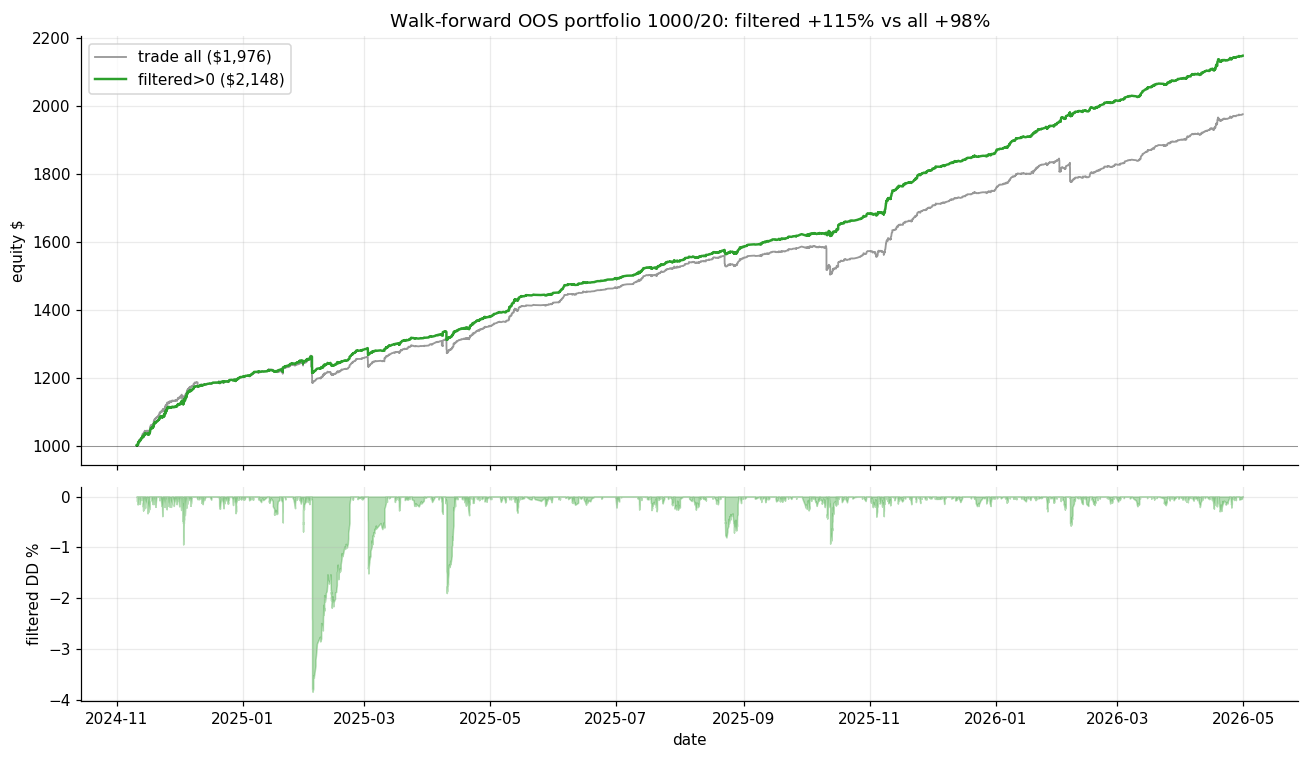

In [3]:
fig,(a1,a2)=plt.subplots(2,1,figsize=(12,7),sharex=True,gridspec_kw={'height_ratios':[2,1]})
a1.plot(sa.index,sa.values,lw=1.2,color='tab:gray',alpha=0.8,label=f'trade all (${eqa:,.0f})')
a1.plot(sf.index,sf.values,lw=1.6,color='tab:green',label=f'filtered>0 (${eqf:,.0f})')
a1.axhline(CAPITAL,color='k',lw=0.6,alpha=0.4); a1.set_ylabel('equity $'); a1.legend(loc='upper left')
a1.set_title(f'Walk-forward OOS portfolio $1000/$20: filtered {(eqf/CAPITAL-1)*100:+.0f}% vs all {(eqa/CAPITAL-1)*100:+.0f}%')
ddf_s=(sf/sf.cummax()-1)*100
a2.fill_between(ddf_s.index,ddf_s.values,0,color='tab:green',alpha=0.35)
a2.set_ylabel('filtered DD %'); a2.set_xlabel('date')
show('14_filtered_portfolio')